# DQN Training Results

Connect to Google Colab CPU or directly login in the browser.

In [1]:
import json
import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1 · Load training logs

In [5]:
LOG_DIR = '/content/drive/MyDrive/Exploration/logs/'

def load_log(path):
    last = None
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                last = json.loads(line)
    return last

log_files = sorted(glob.glob(os.path.join(LOG_DIR, '*.jsonl')))
print(f'Found {len(log_files)} log file(s):')
for p in log_files:
    print(' ', p)

runs = {}
for path in log_files:
    data = load_log(path)
    if data is None:
        print(f'  [WARN] {path} is empty — skipping')
        continue
    
    # Extract run_tag from filename
    filename = os.path.basename(path)
    run_tag, _ = os.path.splitext(filename)  # e.g., 'greedy_1'
    
    runs[run_tag] = data
    print(f'  Loaded {run_tag}: {len(data["rewards"])} episodes')

Found 1 log file(s):
  /content/drive/MyDrive/Exploration/logs/greedy_1.jsonl
  Loaded greedy_1: 5000 episodes


## 2 · Utility: rolling average

In [6]:
def rolling(arr, window=100):
    """Centred rolling mean that handles edges gracefully."""
    arr = np.array(arr, dtype=float)
    out = np.full_like(arr, np.nan)
    for i in range(len(arr)):
        lo = max(0, i - window // 2)
        hi = min(len(arr), i + window // 2 + 1)
        out[i] = arr[lo:hi].mean()
    return out

## 3 · Reward vs Episode

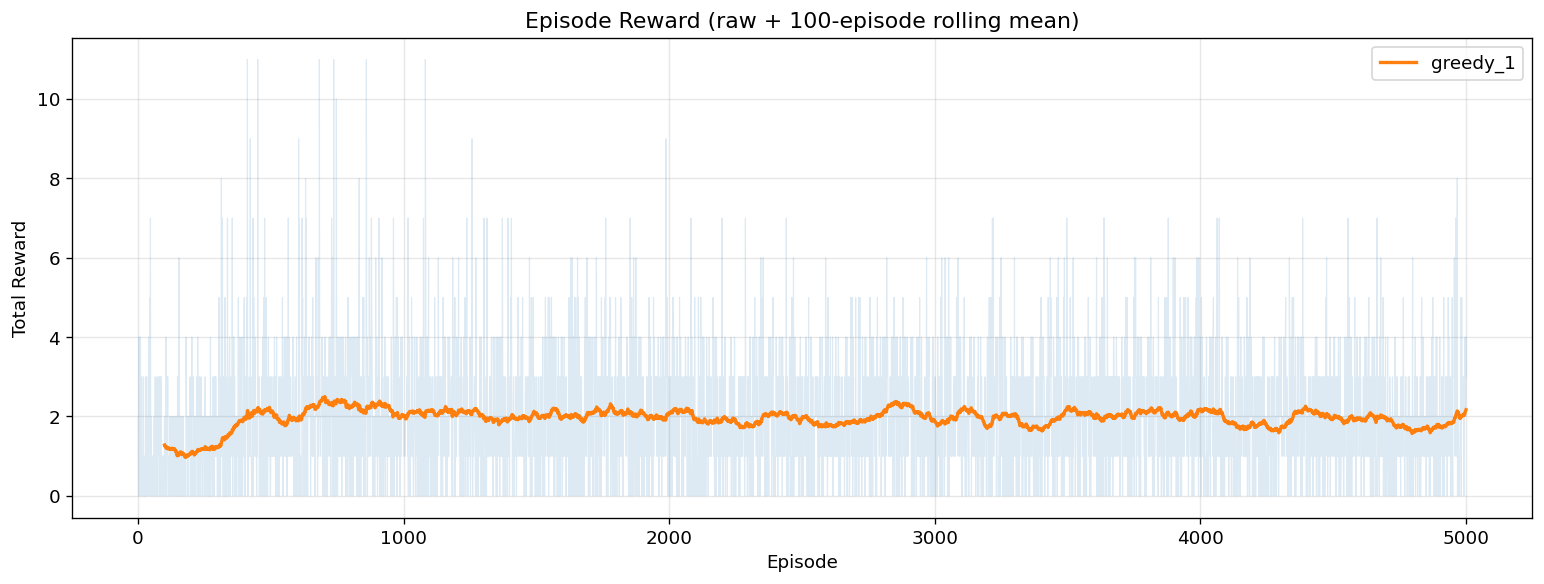

In [20]:
fig, ax = plt.subplots(figsize=(13, 5))

for key, data in runs.items():
    rewards  = np.array(data['rewards'])
    episodes = np.arange(1, len(rewards) + 1)
    smooth   = rolling(rewards, window=100)

    ax.plot(episodes, rewards,  alpha=0.15, linewidth=0.7)
    ax.plot(episodes, smooth,   linewidth=2.0, label=key)

ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward')
ax.set_title('Episode Reward (raw + 100-episode rolling mean)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('reward_vs_episode.png', bbox_inches='tight')
plt.show()

## 4 · Reward vs Samples (environment steps)

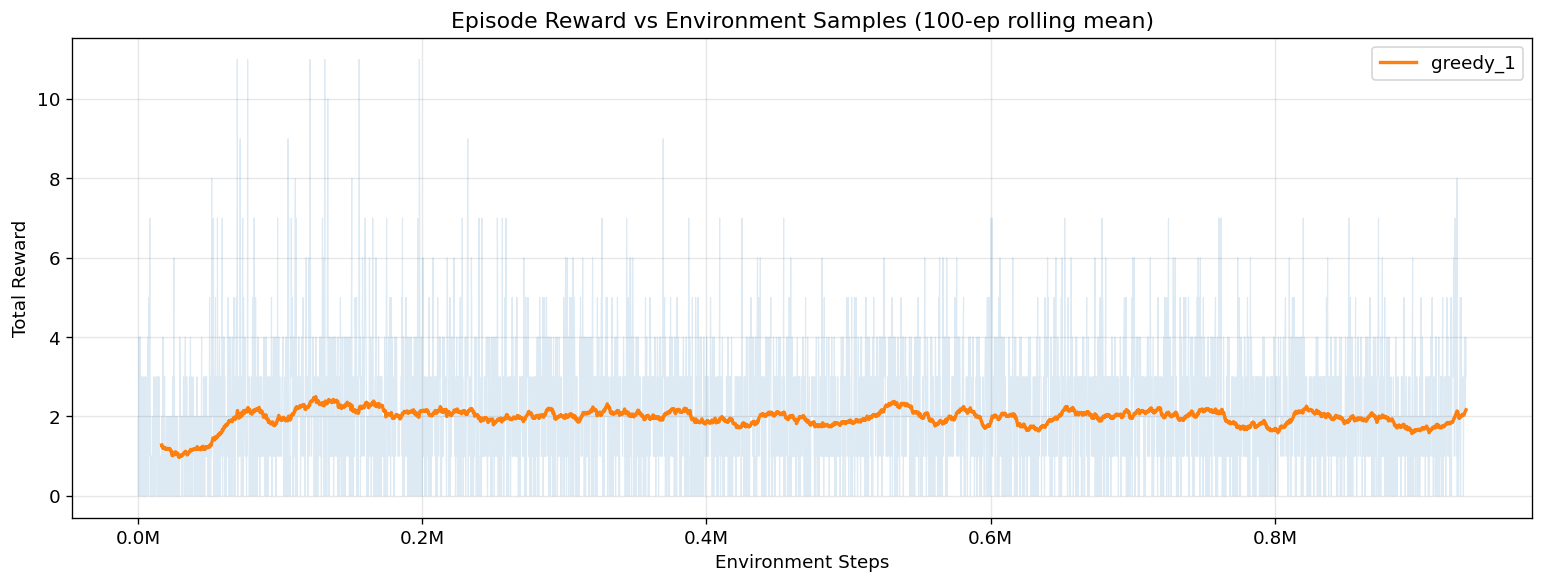

In [21]:
fig, ax = plt.subplots(figsize=(13, 5))

for key, data in runs.items():
    rewards = np.array(data['rewards'])
    steps   = np.array(data['cumulative_steps'])
    smooth  = rolling(rewards, window=100)

    ax.plot(steps, rewards, alpha=0.15, linewidth=0.7)
    ax.plot(steps, smooth,  linewidth=2.0, label=key)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.1f}M'
))
ax.set_xlabel('Environment Steps')
ax.set_ylabel('Total Reward')
ax.set_title('Episode Reward vs Environment Samples (100-ep rolling mean)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('reward_vs_samples.png', bbox_inches='tight')
plt.show()

## 5 · Episode Length vs Episode

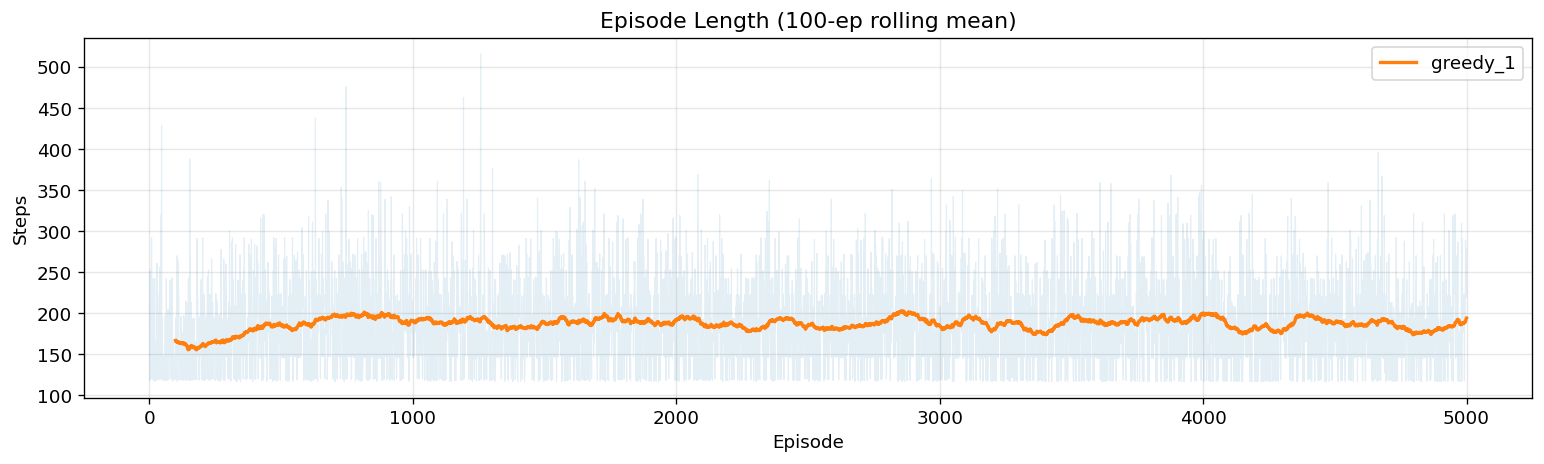

In [22]:
fig, ax = plt.subplots(figsize=(13, 4))

for key, data in runs.items():
    lengths  = np.array(data['episode_lengths'])
    episodes = np.arange(1, len(lengths) + 1)
    smooth   = rolling(lengths, window=100)

    ax.plot(episodes, lengths, alpha=0.12, linewidth=0.7)
    ax.plot(episodes, smooth,  linewidth=2.0, label=key)

ax.set_xlabel('Episode')
ax.set_ylabel('Steps')
ax.set_title('Episode Length (100-ep rolling mean)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('length_vs_episode.png', bbox_inches='tight')
plt.show()